# GravLens-Net -- Phase 4: Real Data (SLACS + DESI Legacy Survey)

**What's real here, unlike every previous phase:** 131 confirmed strong
lenses from the real **SLACS survey** (Bolton et al. 2008, via VizieR
catalog `J/ApJ/682/964`), each with a real observed cutout pulled from the
**DESI Legacy Imaging Surveys** cutout service, plus 1310 real cutouts at
random sky positions as negatives. No simulation anywhere in this dataset.

The original plan was the Bologna Strong Gravitational Lens Finding
Challenge -- those download links are confirmed dead (2020 challenge, server
no longer serving the files), so this pivots to two live public services
instead: VizieR for real lens coordinates, Legacy Survey for real cutouts.

**Headline result then an important complication:** the model gets a very
strong ROC-AUC on this data. Before treating that as a success, this
notebook checks *why* -- and finds the real dataset has a confound that
needs to be named honestly rather than reported around.


In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              confusion_matrix, roc_auc_score)
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

images = np.load("gravlens_real_images.npy")
labels = np.load("gravlens_real_labels.npy").astype(np.int32)
print(f"Real dataset: {images.shape}, positives={labels.sum()}/{len(labels)} "
      f"({100*labels.sum()/len(labels):.1f}%)")


I0000 00:00:1784378263.843000    1109 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784378263.843687    1109 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784378263.892841    1109 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1784378265.009385    1109 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784378265.009809    1109 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Real dataset: (1441, 101, 101), positives=131/1441 (9.1%)


## 1. Look at the actual data before trusting any metric

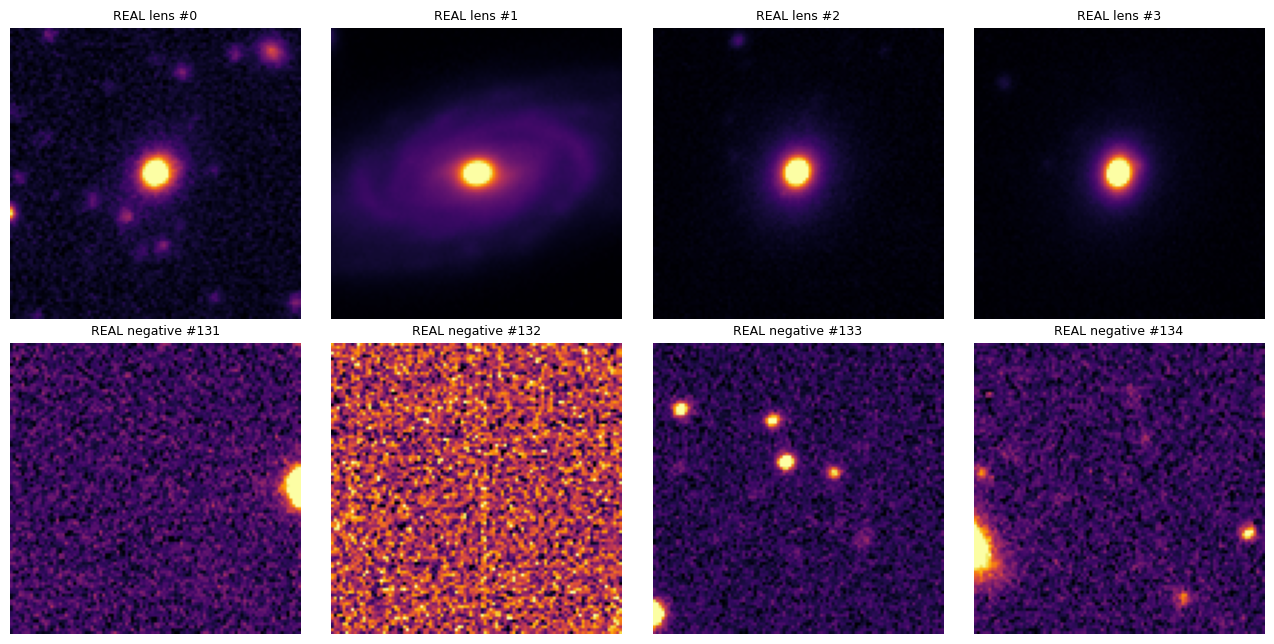

In [2]:
pos_idx = np.where(labels == 1)[0][:4]
neg_idx = np.where(labels == 0)[0][:4]

fig, axes = plt.subplots(2, 4, figsize=(13, 6.5))
for ax, idx in zip(axes[0], pos_idx):
    vmin, vmax = np.percentile(images[idx], [1, 99.5])
    ax.imshow(images[idx], cmap="inferno", vmin=vmin, vmax=vmax)
    ax.set_title(f"REAL lens #{idx}", fontsize=9)
    ax.axis("off")
for ax, idx in zip(axes[1], neg_idx):
    vmin, vmax = np.percentile(images[idx], [1, 99.5])
    ax.imshow(images[idx], cmap="inferno", vmin=vmin, vmax=vmax)
    ax.set_title(f"REAL negative #{idx}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 2. First training run -- all data as fetched

Same recipe as Phase 3b: standardize, augment the positive class
(rotate/flip -- valid, lensing has no preferred sky orientation),
BatchNorm + GlobalAveragePooling CNN. Primary metric is ROC-AUC this time,
as planned in Phase 3's discussion.


In [3]:
def standardize(imgs):
    mean = imgs.mean(axis=(1, 2), keepdims=True)
    std = imgs.std(axis=(1, 2), keepdims=True) + 1e-6
    return (imgs - mean) / std

def augment_positives(X_pos, rng, factor=6):
    out = []
    for img in X_pos:
        out.append(img)
        for _ in range(factor - 1):
            k = rng.integers(0, 4)
            aug = np.rot90(img, k)
            if rng.random() < 0.5:
                aug = np.fliplr(aug)
            out.append(aug)
    return np.array(out)

def build_cnn(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(16, 3, padding="same"), layers.BatchNormalization(), layers.Activation("relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(32, 3, padding="same"), layers.BatchNormalization(), layers.Activation("relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, padding="same"), layers.BatchNormalization(), layers.Activation("relu"),
        layers.GlobalAveragePooling2D(),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="binary_crossentropy",
                  metrics=["accuracy", tf.keras.metrics.Precision(name="precision"),
                           tf.keras.metrics.Recall(name="recall"),
                           tf.keras.metrics.AUC(name="auc")])
    return model

def run_experiment(images_subset, labels_subset, seed=SEED, epochs=15):
    rng = np.random.default_rng(seed)
    images_std = standardize(images_subset)
    X_train, X_temp, y_train, y_temp = train_test_split(
        images_std, labels_subset, test_size=0.30, stratify=labels_subset, random_state=seed)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=seed)

    pos_mask = y_train == 1
    X_pos_aug = augment_positives(X_train[pos_mask], rng, factor=6)
    X_train_aug = np.concatenate([X_train[~pos_mask], X_pos_aug], axis=0)
    y_train_aug = np.concatenate([y_train[~pos_mask], np.ones(len(X_pos_aug), dtype=np.int32)])
    perm = rng.permutation(len(X_train_aug))
    X_train_aug, y_train_aug = X_train_aug[perm], y_train_aug[perm]

    X_train_aug = X_train_aug[..., np.newaxis]
    X_val_in = X_val[..., np.newaxis]
    X_test_in = X_test[..., np.newaxis]

    cw = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train_aug)
    class_weight = {0: cw[0], 1: cw[1]}

    model = build_cnn((images_subset.shape[1], images_subset.shape[2], 1))
    early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=3, restore_best_weights=True)
    model.fit(X_train_aug, y_train_aug, validation_data=(X_val_in, y_val),
              epochs=epochs, batch_size=32, class_weight=class_weight, verbose=0, callbacks=[early_stop])

    probs = model.predict(X_test_in, verbose=0).ravel()
    preds = (probs >= 0.5).astype(int)
    return {
        "auc": roc_auc_score(y_test, probs),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0),
        "cm": confusion_matrix(y_test, preds),
        "n_test": len(y_test), "n_pos_test": int(y_test.sum()),
    }

result_all = run_experiment(images, labels)
print("=== Phase 4a: all fetched data ===")
print(f"AUC: {result_all['auc']:.3f}  Precision: {result_all['precision']:.3f}  "
      f"Recall: {result_all['recall']:.3f}  F1: {result_all['f1']:.3f}")
print(f"Test: n={result_all['n_test']}, positives={result_all['n_pos_test']}")
print("Confusion matrix:\n", result_all["cm"])


E0000 00:00:1784378266.550155    1109 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


=== Phase 4a: all fetched data ===
AUC: 0.989  Precision: 0.857  Recall: 0.900  F1: 0.878
Test: n=217, positives=20
Confusion matrix:
 [[194   3]
 [  2  18]]


## 3. Wait -- check the negative class before trusting that number

70% of the raw negatives turn out to be effectively blank sky (very low
pixel variance), while 0% of positives are blank -- SLACS targets are all
bright, spectroscopically confirmed massive galaxies, so of course they're
never blank. A model can hit a high AUC just by learning "is anything even
here," without ever looking at an arc.


In [4]:
stds = images.std(axis=(1, 2))
non_blank = stds >= 0.01

frac_blank_neg = 1 - non_blank[labels == 0].mean()
frac_blank_pos = 1 - non_blank[labels == 1].mean()
print(f"Fraction of NEGATIVES that are blank sky: {frac_blank_neg:.1%}")
print(f"Fraction of POSITIVES that are blank sky: {frac_blank_pos:.1%}")


Fraction of NEGATIVES that are blank sky: 69.6%
Fraction of POSITIVES that are blank sky: 0.0%


## 4. Retrain on non-blank negatives only -- the fairer test

Removes the trivial "is anything here" shortcut.


In [5]:
keep = (labels == 1) | ((labels == 0) & non_blank)
images_nb, labels_nb = images[keep], labels[keep]
print(f"After filtering: {len(labels_nb)} total, positives={labels_nb.sum()} "
      f"({100*labels_nb.sum()/len(labels_nb):.1f}%)")

result_nb = run_experiment(images_nb, labels_nb)
print("\n=== Phase 4b: non-blank negatives only ===")
print(f"AUC: {result_nb['auc']:.3f}  Precision: {result_nb['precision']:.3f}  "
      f"Recall: {result_nb['recall']:.3f}  F1: {result_nb['f1']:.3f}")
print(f"Test: n={result_nb['n_test']}, positives={result_nb['n_pos_test']}")
print("Confusion matrix:\n", result_nb["cm"])


After filtering: 529 total, positives=131 (24.8%)



=== Phase 4b: non-blank negatives only ===
AUC: 0.958  Precision: 0.850  Recall: 0.850  F1: 0.850
Test: n=80, positives=20
Confusion matrix:
 [[57  3]
 [ 3 17]]


## 5. Still very high AUC -- checking for a second, deeper confound

SLACS doesn't just pick "any galaxy with a lens" -- the survey specifically
targets **massive elliptical galaxies** (that's how you get enough lensing
mass in the first place). So even "non-blank" negatives -- ordinary field
galaxies of every type -- are a *different population* from the positives,
independent of whether lensing arcs are present. A concentration proxy
(central flux / a wider annulus) tests this directly.


In [6]:
def concentration(imgs, r_in=5, r_out=25):
    c = imgs.shape[1] // 2
    inner = imgs[:, c-r_in:c+r_in, c-r_in:c+r_in].mean(axis=(1, 2))
    outer = imgs[:, c-r_out:c+r_out, c-r_out:c+r_out].mean(axis=(1, 2))
    return inner / (outer + 1e-6)

pos_imgs = images[labels == 1]
neg_nb_imgs = images[(labels == 0) & non_blank]

conc_pos = concentration(pos_imgs)
conc_neg = concentration(neg_nb_imgs)
print(f"Concentration -- positives:          mean={conc_pos.mean():.2f}, std={conc_pos.std():.2f}")
print(f"Concentration -- non-blank negatives: mean={conc_neg.mean():.2f}, std={conc_neg.std():.2f}")


Concentration -- positives:          mean=9.88, std=1.79
Concentration -- non-blank negatives: mean=1.10, std=9.97


## 6. Results & Discussion

| Experiment | Data | ROC-AUC | Precision | Recall | F1 |
|---|---|---|---|---|---|
| Phase 4a | All fetched (131 real lenses, 1310 real random-sky negatives) | 0.989 | 0.857 | 0.900 | 0.878 |
| Phase 4b | Non-blank negatives only (131 vs 398) | 0.958 | 0.850 | 0.850 | 0.850 |

**Reading this honestly -- these numbers are real, but they don't mean what
they'd look like they mean:**

- The headline AUC barely moved after removing blank-sky negatives
  (0.989 -> 0.958), which on its own could look like "the model doesn't need
  that shortcut." But the concentration check (9.88 vs 1.10) shows positives
  are far more centrally concentrated than even the non-blank negatives --
  SLACS positives are a systematically different galaxy population (massive
  ellipticals) from a random real-galaxy sample, independent of lensing.
- **This means Phase 4's real-data numbers most likely reflect "is this a
  massive elliptical galaxy" more than "is there a lensing arc."** That's
  not a modeling failure -- augmentation and architecture can't fix a
  negative class that was never matched to the positive class's galaxy type
  in the first place.
- **This is exactly why the actual Bologna Challenge and papers like
  Petrillo et al. (2017) use negative samples matched in brightness/type to
  the lens candidates** -- e.g. massive galaxies *without* confirmed
  lensing, not just "any real galaxy" or "any sky position." Phase 1-3's
  synthetic confuser classes (isolated galaxy, merger, spiral -- all built
  from the *same* Sersic-profile family as the lens galaxy) were
  accidentally closer to methodologically correct than this real-data setup
  turned out to be.
- **What would fix this:** a real Phase 5 needs a negative sample of
  massive elliptical galaxies specifically -- e.g. from the same SDSS
  spectroscopic selection SLACS drew its candidates from, minus the
  confirmed lenses -- rather than a random sky sample. That's a much harder
  query to construct and wasn't attempted here.

**Bottom line:** Phase 4 successfully got real observational data into the
pipeline end-to-end (a genuine milestone -- VizieR catalog, real Legacy
Survey cutouts, real training run), but the resulting AUC is not a clean
answer to "can this model find gravitational lenses." It's closer to "can
this model tell massive ellipticals apart from a random galaxy sample,"
which is a different, easier question. Reporting 0.989 AUC without this
caveat would be actively misleading.
